# **Customer Credit Card Clustering Analysis**

# **Project OverviewThis analysis segments credit card customers into distinct groups using K-Means and DBSCAN clustering algorithms. The goal is to identify customer behavior patterns and enable targeted marketing strategies**

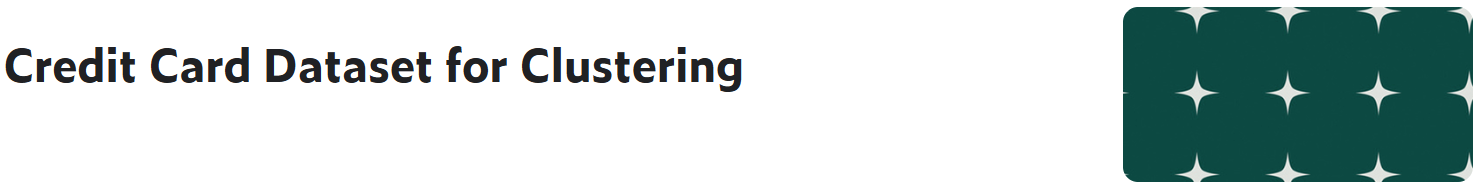

dataset link : (https://www.kaggle.com/datasets/arjunbhasin2013/ccdata?hl=ar-EG

# **Import Libraries**

Import all necessary libraries for data analysis, visualization, and clustering.

* pandas & numpy for data handling

 * matplotlib & plotly for plotting

 * sklearn for preprocessing and KMeans clustering



In [ ]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

# **Load Dataset**




In [ ]:
path = kagglehub.dataset_download("arjunbhasin2013/ccdata")
print("Path:", path)
print(os.listdir(path))


csv_file = os.path.join(path, "CC GENERAL.csv")
data = pd.read_csv(csv_file)


Using Colab cache for faster access to the 'ccdata' dataset.
Path: /kaggle/input/ccdata
['CC GENERAL.csv']


# **Data Understanding**

Perform initial exploration:

 * View the first few rows

 * Check column types and non-null counts

* Get summary statistics for numerical columns

In [ ]:
data.head()


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [ ]:
data.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [ ]:
data.describe()


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


# **Missing Values Detection**

Check for missing values in each column to determine if imputation is needed.

In [ ]:
print(data.isnull().sum())


CUST_ID                               0
BALANCE                               0
BALANCE_FREQUENCY                     0
PURCHASES                             0
ONEOFF_PURCHASES                      0
INSTALLMENTS_PURCHASES                0
CASH_ADVANCE                          0
PURCHASES_FREQUENCY                   0
ONEOFF_PURCHASES_FREQUENCY            0
PURCHASES_INSTALLMENTS_FREQUENCY      0
CASH_ADVANCE_FREQUENCY                0
CASH_ADVANCE_TRX                      0
PURCHASES_TRX                         0
CREDIT_LIMIT                          1
PAYMENTS                              0
MINIMUM_PAYMENTS                    313
PRC_FULL_PAYMENT                      0
TENURE                                0
dtype: int64


# **Handle Missing Values**

Replace missing values with the median to maintain the data distribution without distortion.

In [ ]:
data['MINIMUM_PAYMENTS'].fillna(data['MINIMUM_PAYMENTS'].median(), inplace=True)
data['CREDIT_LIMIT'].fillna(data['CREDIT_LIMIT'].median(), inplace=True)

/tmp/ipython-input-2392440272.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['MINIMUM_PAYMENTS'].fillna(data['MINIMUM_PAYMENTS'].median(), inplace=True)
/tmp/ipython-input-2392440272.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].meth

# **Verify After Handling**

In [ ]:
print(data.isnull().sum())


CUST_ID                             0
BALANCE                             0
BALANCE_FREQUENCY                   0
PURCHASES                           0
ONEOFF_PURCHASES                    0
INSTALLMENTS_PURCHASES              0
CASH_ADVANCE                        0
PURCHASES_FREQUENCY                 0
ONEOFF_PURCHASES_FREQUENCY          0
PURCHASES_INSTALLMENTS_FREQUENCY    0
CASH_ADVANCE_FREQUENCY              0
CASH_ADVANCE_TRX                    0
PURCHASES_TRX                       0
CREDIT_LIMIT                        0
PAYMENTS                            0
MINIMUM_PAYMENTS                    0
PRC_FULL_PAYMENT                    0
TENURE                              0
dtype: int64


# **Outlier Detection**

Explore the distribution of MINIMUM_PAYMENTS to identify extreme values

In [ ]:
data['MINIMUM_PAYMENTS'].describe()


,MINIMUM_PAYMENTS
count,8950.000000
mean,844.906767
std,2332.792322
min,0.019163
25%,170.857654
50%,312.343947
75%,788.713501
max,76406.207520


# **Visualization (Before Handling)**

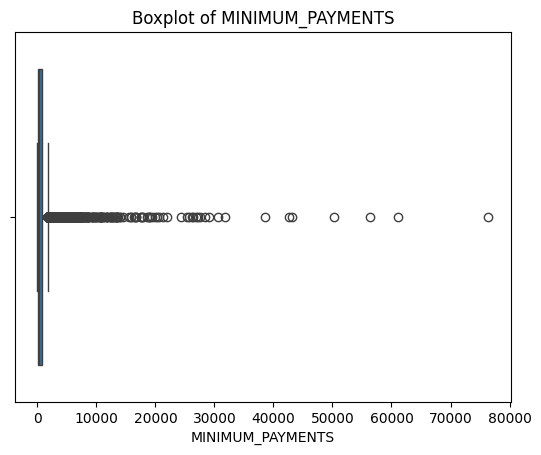

In [ ]:
import seaborn as sns

sns.boxplot(x=data['MINIMUM_PAYMENTS'])
plt.title("Boxplot of MINIMUM_PAYMENTS")
plt.show()


# **Identify Outliers with IQR**

Detect outliers using the Interquartile Range (IQR) method.

In [ ]:
Q1 = data['MINIMUM_PAYMENTS'].quantile(0.25)
Q3 = data['MINIMUM_PAYMENTS'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[
    (data['MINIMUM_PAYMENTS'] < lower_bound) |
    (data['MINIMUM_PAYMENTS'] > upper_bound)
]

print("Number of outliers:", len(outliers))


Number of outliers: 909


# **Outlier Treatment (Clipping)**

Apply clipping to reduce the effect of extreme values while keeping all observations.

In [ ]:
# clipping
data['MINIMUM_PAYMENTS'] = np.clip(
    data['MINIMUM_PAYMENTS'],
    lower_bound,
    upper_bound
)

# "Before outlier treatment, the MINIMUM_PAYMENTS feature showed extreme values reaching up to 80,000, which could heavily bias distance-based clustering algorithms like KMeans.

# **After applying the IQR method with clipping, the feature distribution became more balanced, reducing the influence of extreme values while preserving all observations. This made the data more suitable for clustering. **

# **Statistics After Handling**

In [ ]:
data['MINIMUM_PAYMENTS'].describe()


,MINIMUM_PAYMENTS
count,8950.000000
mean,556.752385
std,532.174180
min,0.019163
25%,170.857654
50%,312.343947
75%,788.713501
max,1715.497271


# **Visualize After Outlier Treatment**

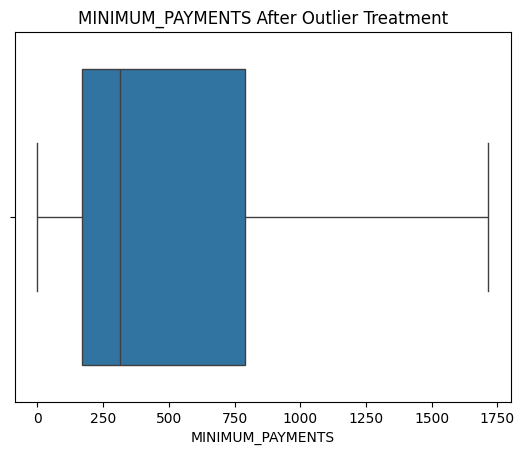

In [ ]:
sns.boxplot(x=data['MINIMUM_PAYMENTS'])
plt.title("MINIMUM_PAYMENTS After Outlier Treatment")
plt.show()


In [ ]:
print(data.shape)


(8950, 18)


# **Prepare Data for Clustering**

The customer ID column was removed as it is an identifier and does not carry numerical meaning for clustering.


In [ ]:
X = data.drop(columns=['CUST_ID'])


# **SCALING**

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)


# **KMeans**

# **Elbow Method to Find Optimal K**

Use the Elbow Method to determine the optimal number of clusters for KMeans.

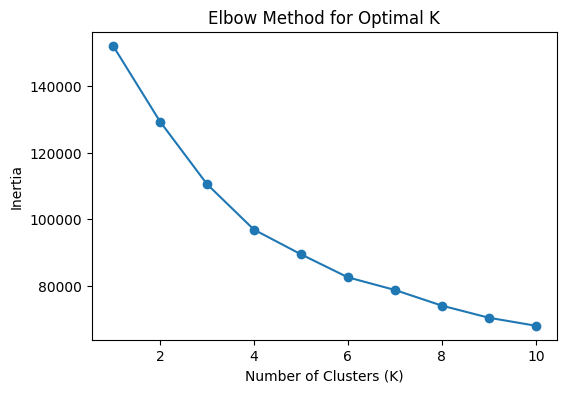

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()


# **KMeans Clustering**

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

data['KMeans_Cluster'] = kmeans_labels


# **Cluster Analysis**

Analyze clusters:


* Count of customers in each cluster

* Calculate mean values for each numerical column per cluster to interpret customer behavior

In [ ]:
data['KMeans_Cluster'].value_counts()


,count
KMeans_Cluster,
1,3938
2,3298
0,1300
3,414


In [ ]:
numeric_data = data.select_dtypes(include=np.number)
numeric_data.groupby(data['KMeans_Cluster']).mean()


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,KMeans_Cluster
KMeans_Cluster,,,,,,,,,,,,,,,,,,
0,4681.914529,0.971368,516.717023,325.024477,191.787677,4222.719987,0.297717,0.139827,0.195584,0.453466,13.258462,7.913077,7563.234266,3393.588901,1259.623758,0.030786,11.494615,0.0
1,933.867428,0.785584,270.440960,208.643652,62.061320,597.844856,0.173692,0.086743,0.083476,0.116151,2.160488,2.958354,3192.966819,943.065590,398.824385,0.079519,11.411376,1.0
2,830.784792,0.935770,1238.283545,594.566731,643.996765,190.415221,0.886882,0.298094,0.713031,0.039865,0.734688,22.089145,4184.102563,1329.398217,422.548520,0.275313,11.598241,2.0
3,3618.508807,0.987915,7628.250000,5065.852343,2563.846932,698.207804,0.948474,0.737956,0.790217,0.075260,2.198068,89.048309,9706.642512,7250.783320,920.984330,0.276804,11.951691,3.0


# **kmeans_silhouette**

# Silhouette score was calculated for both algorithms to quantitatively compare cluster quality. For DBSCAN, noise points were excluded from the calculation, while for K-Means the score was computed on the entire dataset.

In [ ]:
from sklearn.metrics import silhouette_score

kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
kmeans_silhouette


np.float64(0.19459869289245932)

# **DBSCAN Clustering:**

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


# DBSCAN Clustering

#DBSCAN is a density-based clustering algorithm that groups points closely packed together and identifies noise points that do not belong to any cluster


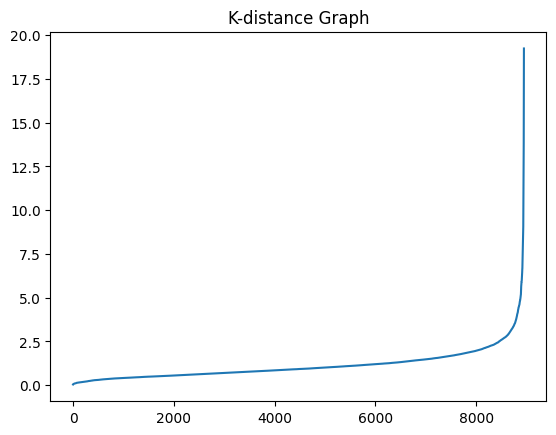

In [ ]:
from sklearn.neighbors import NearestNeighbors
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, _ = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 4])

plt.plot(distances)
plt.title("K-distance Graph")
plt.show()
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

data['DBSCAN_Cluster'] = dbscan_labels


# **Dimensionality Reduction for Visualization (PCA)**

# Since the dataset has many dimensions, PCA is used to reduce it to 2 components for visualization purposes only.



In [ ]:
pca = PCA(n_components=2, random_state=42)
pca_data = pca.fit_transform(X_scaled)


# **DBSCAN Visualization**

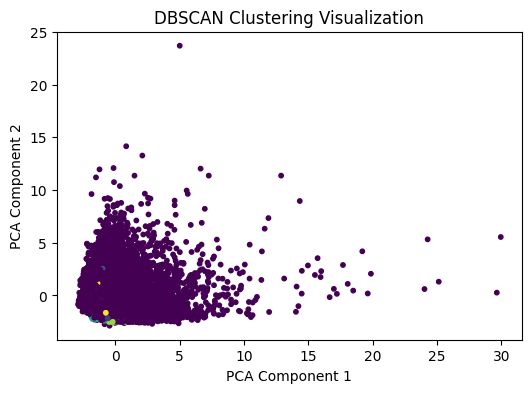

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(
    pca_data[:, 0],
    pca_data[:, 1],
    c=dbscan_labels,
    cmap='viridis',
    s=10
)
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("DBSCAN Clustering Visualization")
plt.show()


-1 = Noise (outliers)

# **DBSCAN Evaluation (Silhouette Score)**

# Remove noise points (-1) before calculating silhouette score

In [ ]:
mask = dbscan_labels != -1

dbscan_silhouette = silhouette_score(
    X_scaled[mask],
    dbscan_labels[mask]
)

dbscan_silhouette


np.float64(-0.25184303692079035)

# **DBSCAN Cluster Analysis**

In [ ]:
numeric_data = data.select_dtypes(include=np.number)

numeric_data.groupby(data['DBSCAN_Cluster']).mean()


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,KMeans_Cluster,DBSCAN_Cluster
DBSCAN_Cluster,,,,,,,,,,,,,,,,,,,
-1,1821.027548,0.883157,1256.412201,760.924289,495.868107,1224.125587,0.533267,0.252688,0.383408,0.157562,3.950954,17.706902,5175.348722,2126.673013,615.504690,0.162314,11.397944,1.324523,-1.0
0,882.591553,0.995933,188.454673,50.520833,137.947605,233.676409,0.342452,0.033723,0.304886,0.082244,1.311081,5.103235,2102.924983,506.480871,362.569961,0.087009,12.000000,1.291122,0.0
1,1318.675696,1.000000,589.724643,9.258929,580.465714,7.934289,0.985119,0.011905,0.985119,0.008929,0.107143,15.285714,1278.571429,670.102542,1701.072203,0.000000,12.000000,2.000000,1.0
2,984.442150,0.875000,0.000000,0.000000,0.000000,1221.011916,0.000000,0.000000,0.000000,0.125000,1.375000,0.000000,1775.000000,400.356012,245.698691,0.000000,8.000000,1.000000,2.0
3,1939.295176,1.000000,22.123333,19.705185,2.418148,181.440708,0.018518,0.012346,0.006173,0.114197,1.888889,0.222222,1998.148148,414.392275,1715.497271,0.003086,12.000000,1.000000,3.0
4,29.149033,0.530303,288.883333,15.271667,273.611667,0.000000,0.472222,0.013889,0.430556,0.000000,0.000000,7.500000,1333.333333,557.631746,153.414566,1.000000,12.000000,1.666667,4.0
5,49.632927,1.000000,618.156364,0.001818,618.154545,0.000000,0.984849,0.007576,0.962121,0.000000,0.000000,20.000000,7181.818182,604.895422,173.523159,0.992424,12.000000,2.000000,5.0
6,45.130583,1.000000,239.420000,0.000000,239.420000,0.000000,1.000000,0.000000,0.833333,0.000000,0.000000,6.000000,1333.333333,194.374740,80.448116,0.500000,6.000000,2.000000,6.0
7,28.280560,0.270707,161.690578,126.365867,35.535822,0.000000,0.134444,0.063704,0.063704,0.000000,0.000000,1.897778,2915.777778,326.202546,149.555502,0.003313,12.000000,1.000000,7.0


# **KMeans vs DBSCAN Comparison**

In [ ]:
comparison = pd.DataFrame({
    "Algorithm": ["K-Means", "DBSCAN"],
    "Silhouette Score": [kmeans_silhouette, dbscan_silhouette],
    "Number of Clusters": [
        len(np.unique(kmeans_labels)),
        len(np.unique(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    ],
    "Handles Noise": ["No", "Yes"]
})

comparison


,Algorithm,Silhouette Score,Number of Clusters,Handles Noise
0,K-Means,0.194599,4,No
1,DBSCAN,-0.251843,43,Yes




K-Means produced stable and well-separated clusters that were easy to interpret,
making it suitable for customer segmentation tasks.

DBSCAN successfully identified dense regions and detected noise points, but its
performance was sensitive to parameter selection (eps and min_samples).

Overall, K-Means was more appropriate for this dataset, while DBSCAN provided
valuable insights for detecting anomalies and outliers.
""")
